Reading logs from: /home/christos/shielded/jupyter/2026-01-14/all_logs/
Processing complete.
  - Unique Blocks Created: 90
  - Total Import Events: 1798

Sample Data (First 5 rows):
      Block    Node  ImportTime_ms         Hash
0      3025   alice          222.0  0xd791…91c2
1349   3025    paul          139.0  0xd791…91c2
630    3025    mike            0.0  0xd791…91c2
810    3025  oliver          147.0  0xd791…91c2
1618   3025     sam           78.0  0xd791…91c2

Graph saved as 'import_times_hash_matched.png'


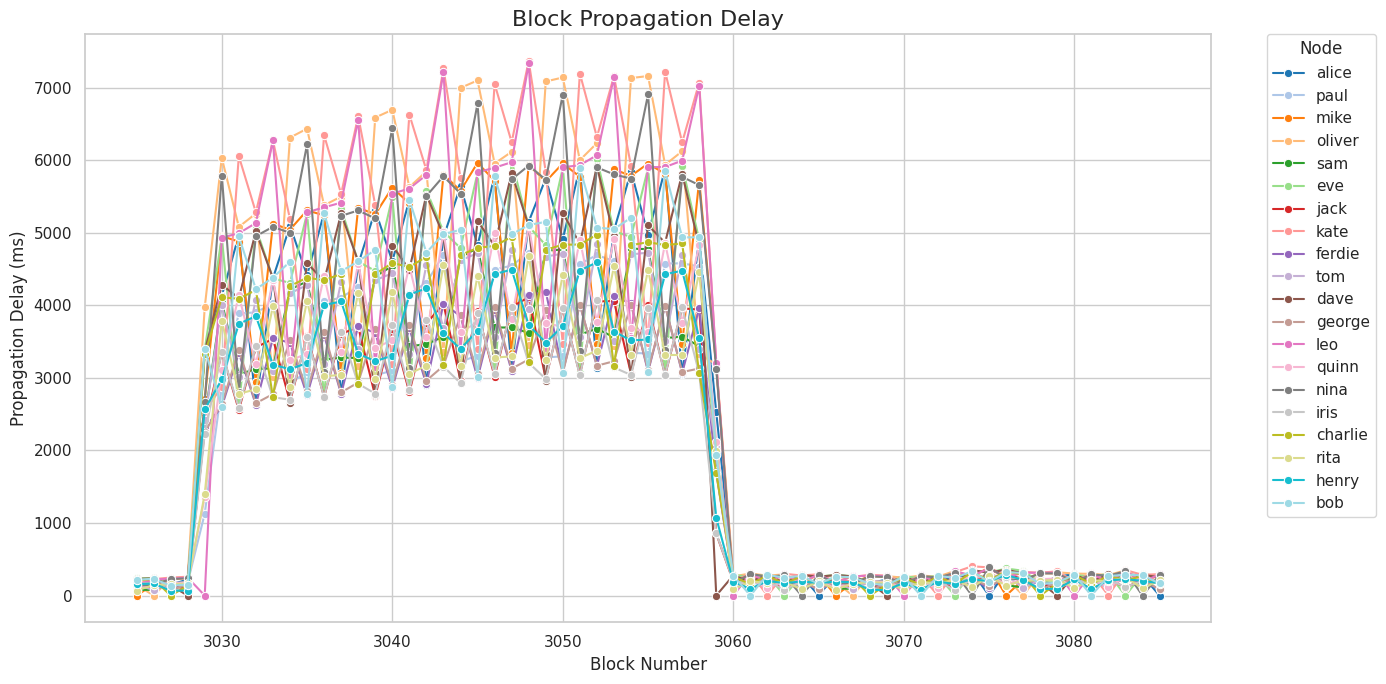

In [8]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

# ---------------------------------------------------------
# STEP 1: CONFIGURATION
# ---------------------------------------------------------
empty_blocks = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/logs/from_2026-01-15_17-35-00_to_2026-01-15_17-50-00/'
test_490_txs = '/home/christos/shielded/jupyter/2026-01-14/all_logs/'
new_200_txs = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/logs/from_2026-01-15_21-38-08_to_2026-01-15_21-44-01/'

# Set active log directory here
logs_dir = test_490_txs

BLOCK_PRODUCERS = [
    "alice", "bob", "charlie", "dave", "eve", "kate", "leo", "mike", "nina", "oliver",
    "ferdie", "george", "henry", "iris", "jack", "paul", "quinn", "rita", "sam", "tom"
]

# ---------------------------------------------------------
# STEP 2: HELPER FUNCTIONS
# ---------------------------------------------------------

def to_short_hash(full_hash):
    """
    Converts a full hash (e.g. 0xf2d38b...ed171) to the log format (0xf2d3…d171).
    Standard Substrate log format is usually: 0x + first 4 + … + last 4
    """
    if not full_hash.startswith("0x"):
        return full_hash
    
    # Remove 0x prefix for slicing
    clean = full_hash[2:]
    if len(clean) < 8: return full_hash
    
    return f"0x{clean[:4]}…{clean[-4:]}"

# ---------------------------------------------------------
# STEP 3: PARSE THE FILES
# ---------------------------------------------------------

# Dictionary to store creation times keyed by the BLOCK HASH (Short format)
# Key: ShortHash (str), Value: { 'time': datetime, 'block_num': int, 'node': str }
creation_registry = {}

# List to store raw import events to be processed later
# Item: { 'time': datetime, 'block_num': int, 'short_hash': str, 'node': str }
import_events = []

# Regex patterns
timestamp_pattern = re.compile(r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d+)")

# Capture Creation: "Pre-sealed block for proposal at 3040. Hash now 0xf2d3..."
# We use the "Pre-sealed" line because it contains the final finalized hash.
creation_pattern = re.compile(r"Pre-sealed block for proposal at (\d+)\. Hash now (0x[a-fA-F0-9]+)")

# Capture Import: "Imported #3040 (0x4e7c…cc64 → 0xf2d3…d171)"
# We capture Group 1 (Block Num) and Group 2 (The second hash, which is the new block hash)
import_pattern = re.compile(r"Imported #(\d+) \(.*? → (0x[a-fA-F0-9…\.]+)\)")

print(f"Reading logs from: {logs_dir}")

for node in BLOCK_PRODUCERS:
    filepath = os.path.join(logs_dir, f"{node}.txt")
    
    if not os.path.exists(filepath):
        print(f"  - Warning: Log file not found for {node}")
        continue
        
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            
            # 1. Extract Timestamp
            ts_match = timestamp_pattern.search(line)
            if not ts_match: continue
            
            try:
                ts_str = ts_match.group(1)
                # Truncate microseconds if too long (Python limit)
                if len(ts_str.split('.')[-1]) > 6: ts_str = ts_str[:26] 
                current_time = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
            except ValueError:
                continue 

            # 2. Check for BLOCK CREATION (The Source of Truth)
            create_match = creation_pattern.search(line)
            if create_match:
                block_num = int(create_match.group(1))
                full_hash = create_match.group(2)
                short_hash = to_short_hash(full_hash)
                
                # We store this hash as the canonical creation event
                creation_registry[short_hash] = {
                    'time': current_time,
                    'block_num': block_num,
                    'creator': node
                }
                continue

            # 3. Check for BLOCK IMPORT
            import_match = import_pattern.search(line)
            if import_match:
                block_num = int(import_match.group(1))
                imported_hash = import_match.group(2)
                
                import_events.append({
                    'time': current_time,
                    'block_num': block_num,
                    'short_hash': imported_hash,
                    'node': node
                })

print(f"Processing complete.")
print(f"  - Unique Blocks Created: {len(creation_registry)}")
print(f"  - Total Import Events: {len(import_events)}")

# ---------------------------------------------------------
# STEP 4: CALCULATE LATENCY (MATCHING BY HASH)
# ---------------------------------------------------------

data = []

for event in import_events:
    target_hash = event['short_hash']
    importer = event['node']
    import_time = event['time']
    
    # Only calculate if we have a creation record for THIS SPECIFIC HASH
    if target_hash in creation_registry:
        genesis_info = creation_registry[target_hash]
        creation_time = genesis_info['time']
        creator = genesis_info['creator']
        block_num = genesis_info['block_num']
        
        # If this node is the creator, latency is 0
        if importer == creator:
            delay_ms = 0.0
        else:
            delta = import_time - creation_time
            delay_ms = delta.total_seconds() * 1000.0
        
        data.append({
            "Block": block_num,
            "Node": importer,
            "ImportTime_ms": delay_ms,
            "Hash": target_hash
        })

# ---------------------------------------------------------
# STEP 5: PLOT
# ---------------------------------------------------------

if not data:
    print("No matching hash data found! Check if the log format matches the patterns.")
else:
    df = pd.DataFrame(data)
    df = df.sort_values(by="Block")
    
    # Display sample to verify
    print("\nSample Data (First 5 rows):")
    print(df.head())

    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    sns.lineplot(
        data=df, 
        x="Block", 
        y="ImportTime_ms", 
        hue="Node", 
        marker="o",
        palette="tab20", 
        linewidth=1.5,
        errorbar=None 
    )

    plt.title("Block Propagation Delay", fontsize=16)
    plt.xlabel("Block Number", fontsize=12)
    plt.ylabel("Propagation Delay (ms)", fontsize=12)
    
    # Formatting X-axis
    if df["Block"].nunique() < 20:
        plt.xticks(df["Block"].unique())

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Node")
    plt.tight_layout()
    
    plt.savefig("import_times_hash_matched.png", dpi=300)
    print("\nGraph saved as 'import_times_hash_matched.png'")
    
    plt.show()

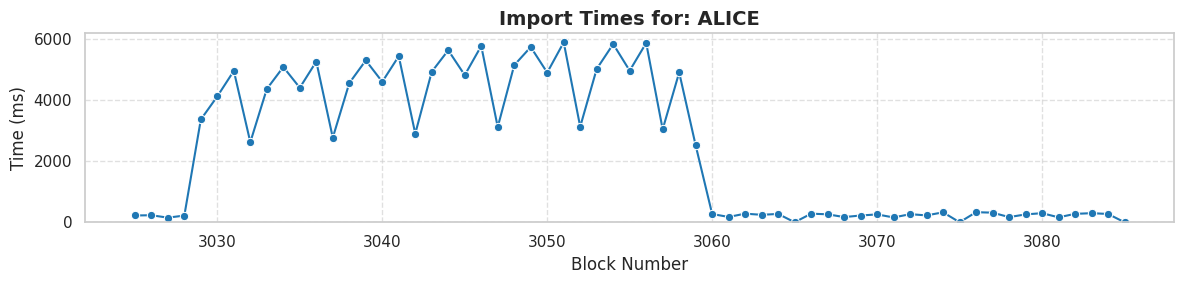

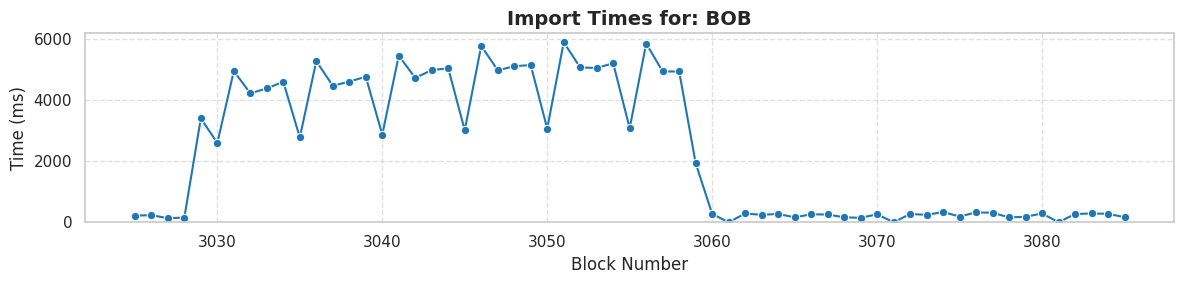

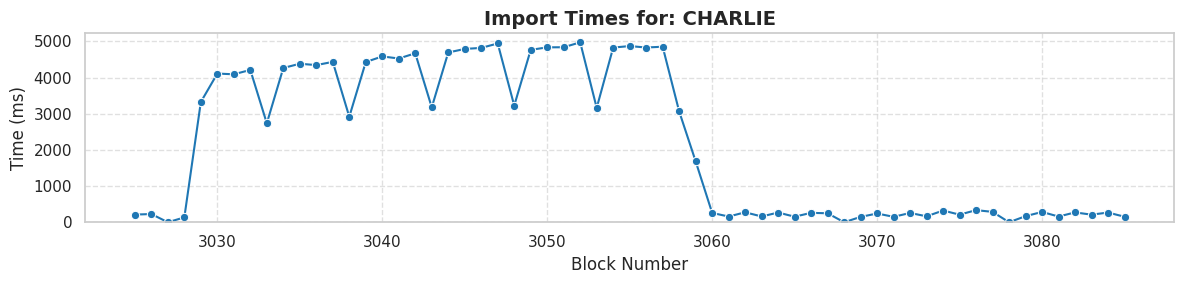

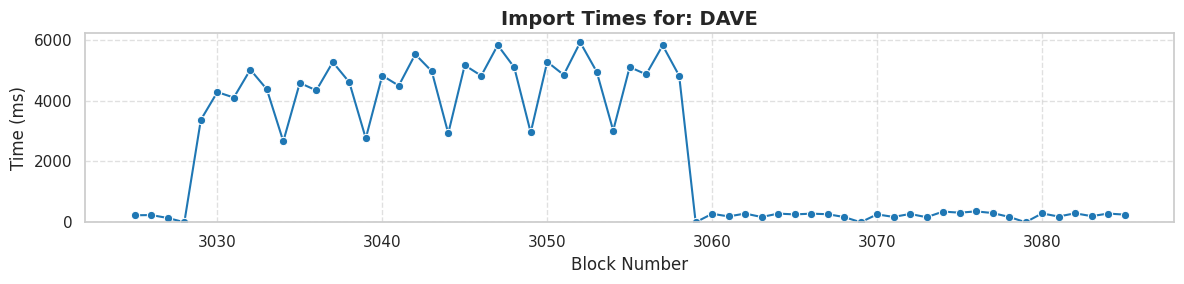

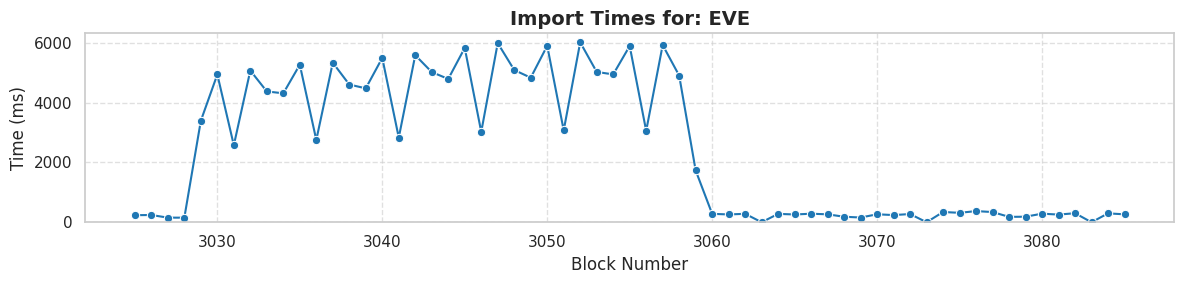

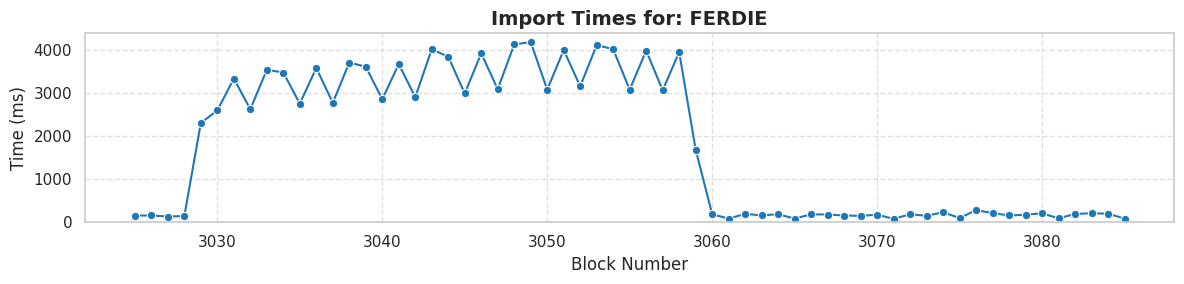

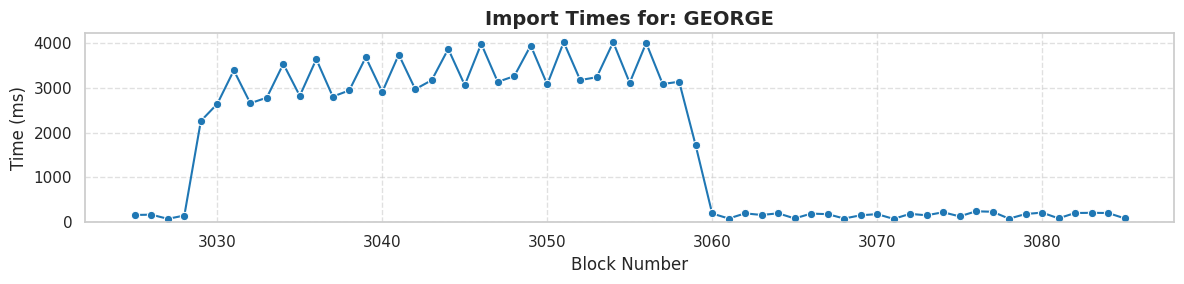

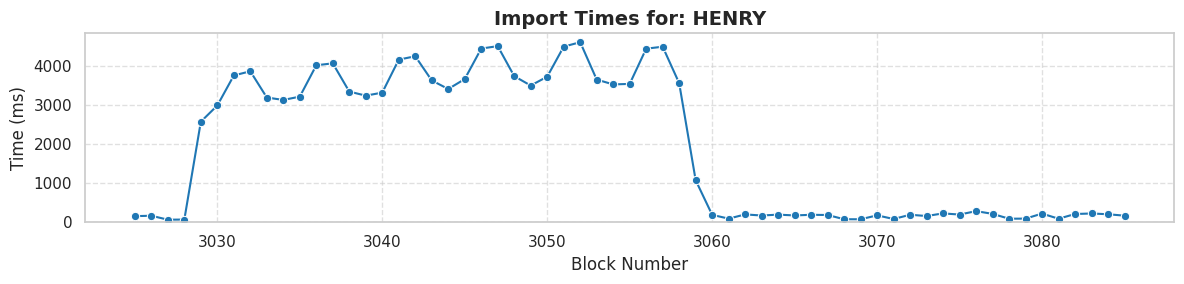

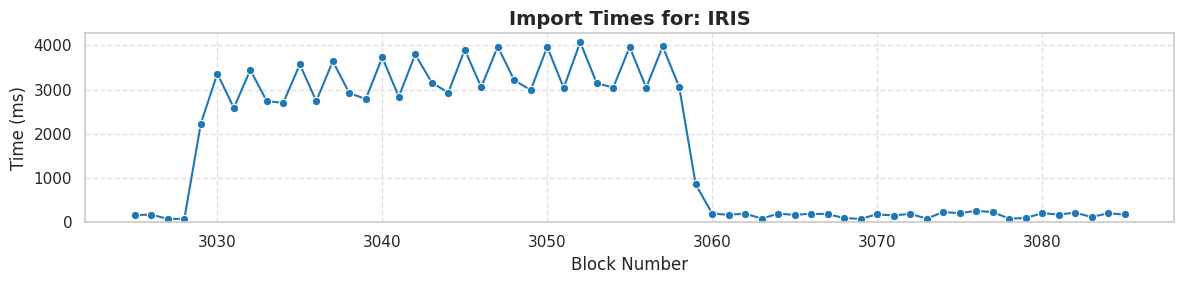

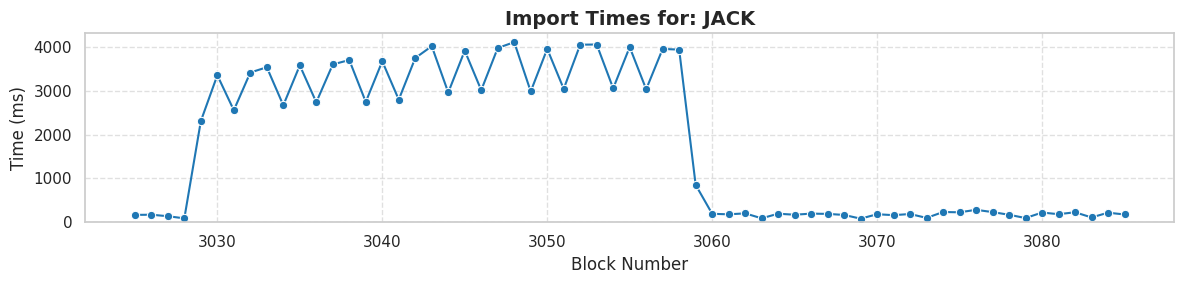

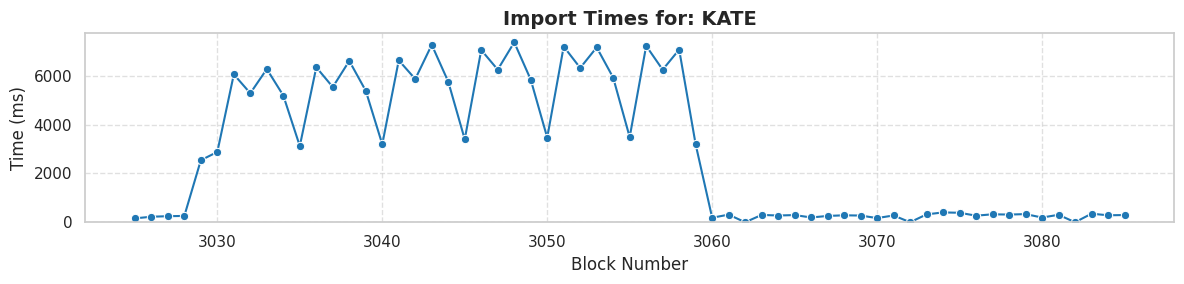

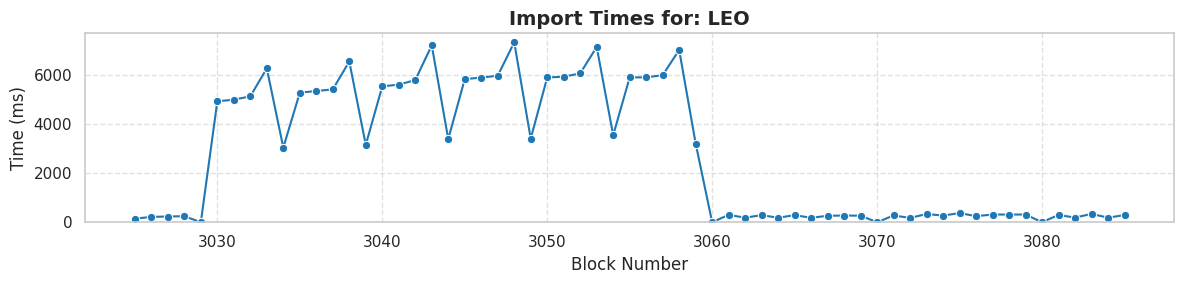

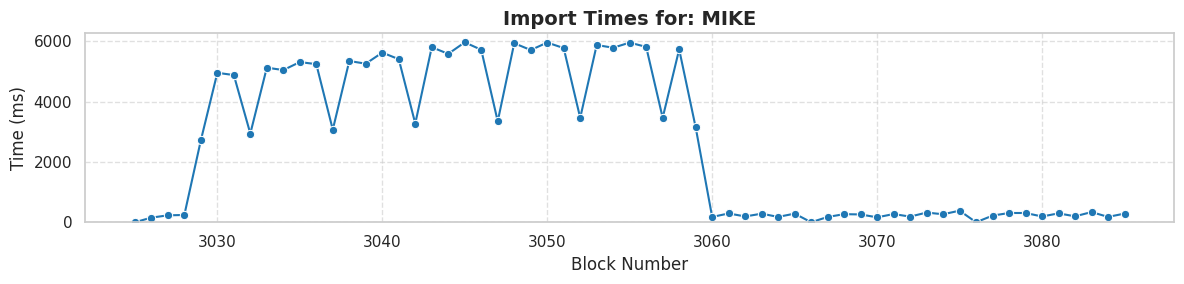

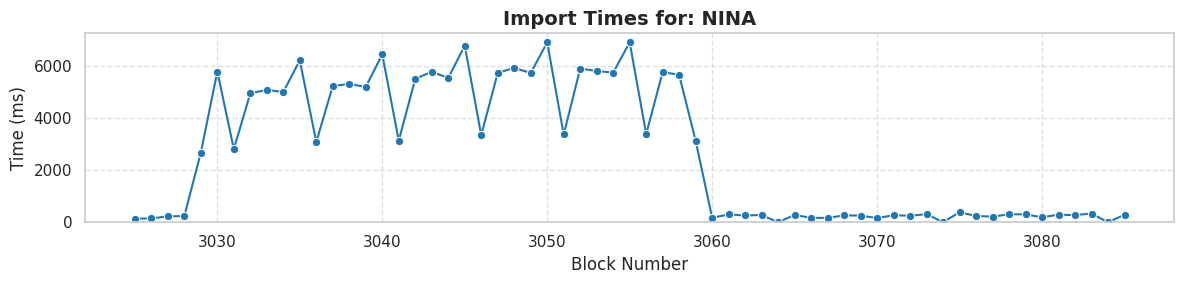

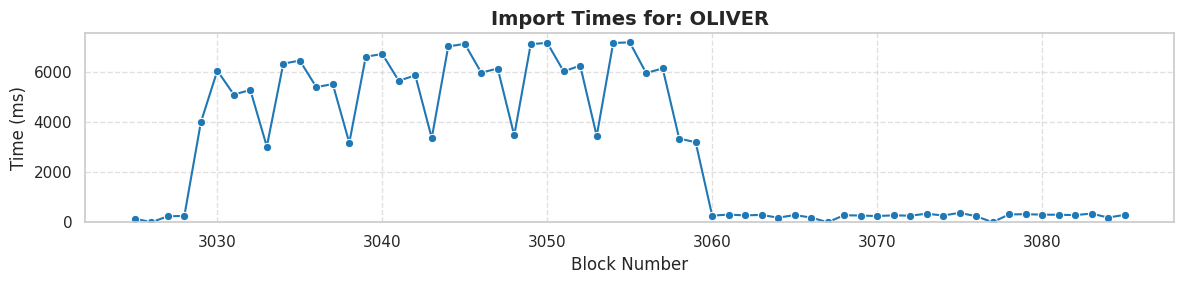

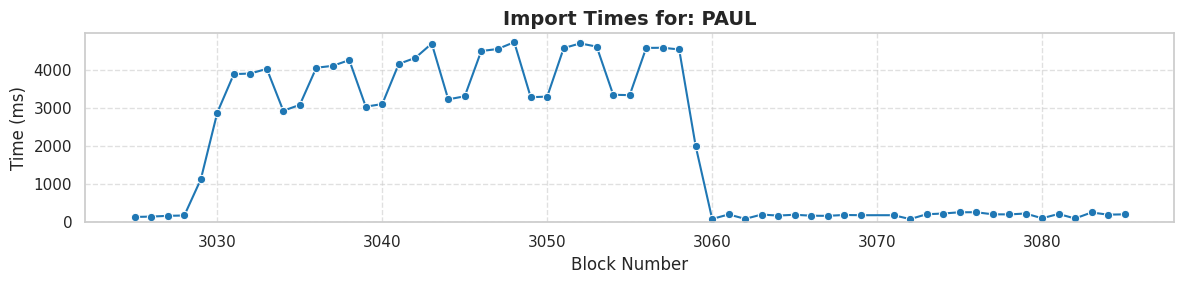

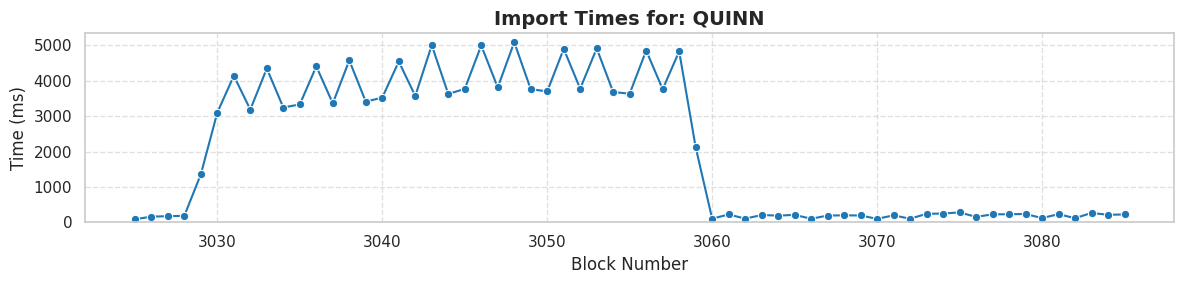

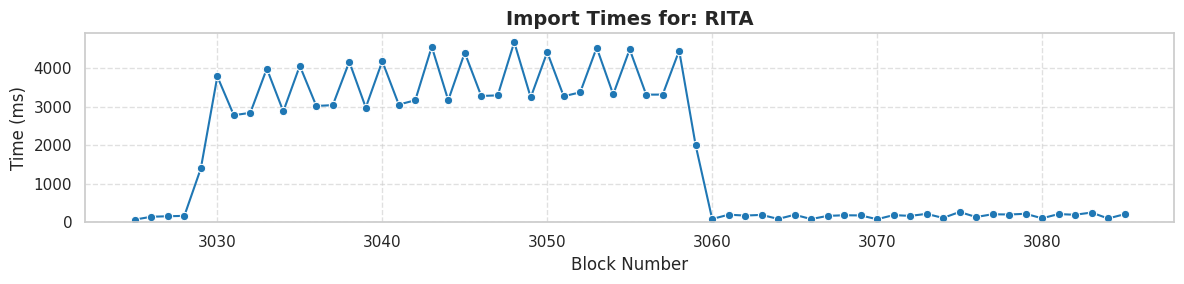

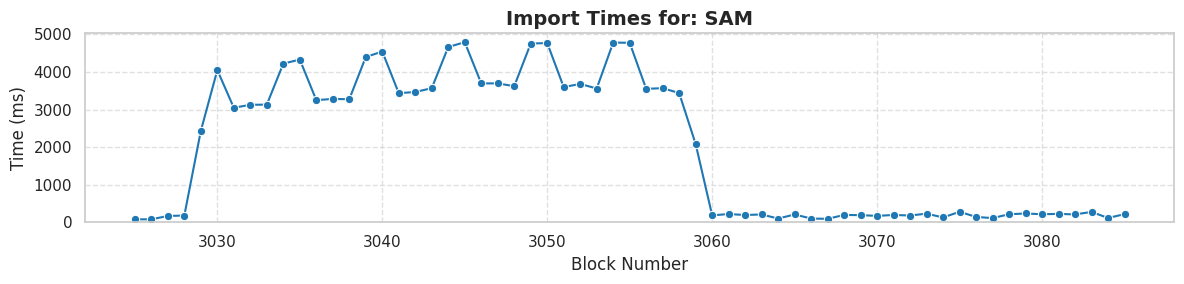

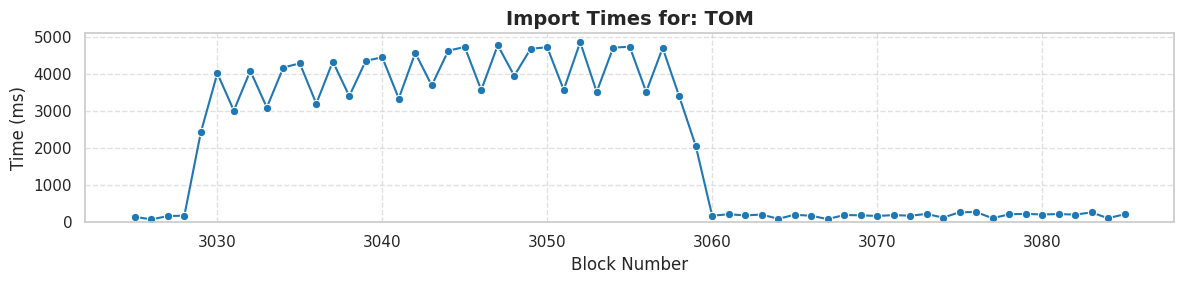

In [9]:
# Get a list of all unique nodes and sort them alphabetically
nodes = sorted(df['Node'].unique())

# Loop through each node and create a separate graph
for node in nodes:
    # 1. Filter the data for just this node
    node_data = df[df['Node'] == node]
    
    # 2. Create a new figure for this node
    plt.figure(figsize=(12, 3)) # Wide and short format
    
    # 3. Plot the line
    sns.lineplot(
        data=node_data, 
        x="Block", 
        y="ImportTime_ms", 
        marker="o",
        color='tab:blue',
        errorbar=None
    )
    
    # 4. formatting
    plt.title(f"Import Times for: {node.upper()}", fontsize=14, fontweight='bold')
    plt.ylabel("Time (ms)")
    plt.xlabel("Block Number")
    
    # Optional: Force the Y-axis to start at 0 to see scale better
    plt.ylim(bottom=0)
    
    # Ensure X-axis shows every block integer (if list isn't too long)
    if len(df["Block"].unique()) < 50:
        plt.xticks(df["Block"].unique())
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # 5. Display the graph
    plt.show()